# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

# Simulating data

## Single df

### Creating

In [2]:
gdf_output = return_spatial_geo_df(n_x = 40,  
    n_y = 25,    
    spacing = 100, 
    treated_scope_x_start = 7,
    treated_scope_x_end = 14,
    treated_scope_y_start = 11,
    treated_scope_y_end = 24,
    ATT_target = 1.5,
    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 17,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 13,
    rho = 0.15,
    spatial_confounder_scope_x_start = 15,
    spatial_confounder_scope_x_end = 32,
    spatial_confounder_scope_y_start = 14,
    spatial_confounder_scope_y_end = 20,
    lambda_cs = 0.2,
    distance_ring_number = 2,
    distance_ring_ate_scalars=[0.4, 0.15],
    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

#### Numerical checks

In [3]:
gdf_output

,unit_id,geometry,x,y,T,propensity,C1,C2,C3,Cs,tau,spill,Y,Y_ns
0,1000,POINT (0 0),0,0,0,0.572536,1.715537,-1.101485,-2.212533,1.512739,0.0,0.0,0.587672,0.587672
1,1001,POINT (0 100),0,100,0,2.169581,0.656220,0.582575,-0.069076,1.182808,0.0,0.0,1.491910,1.491910
2,1002,POINT (0 200),0,200,0,-1.965764,-2.264733,-1.250191,0.387994,0.357565,0.0,0.0,-1.070456,-1.070456
3,1003,POINT (0 300),0,300,0,1.994830,0.223503,1.008799,-0.086214,1.388131,0.0,0.0,1.321698,1.321698
4,1004,POINT (0 400),0,400,0,1.276548,1.352052,-0.745832,-0.119132,0.575885,0.0,0.0,1.051926,1.051926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1995,POINT (3900 2000),3900,2000,0,1.863310,1.089660,0.725001,0.247396,-0.321947,0.0,0.0,1.063449,1.063449
996,1996,POINT (3900 2100),3900,2100,0,0.951730,-0.407031,1.082108,1.486585,-0.564559,0.0,0.0,0.325172,0.325172
997,1997,POINT (3900 2200),3900,2200,0,-1.728875,-0.791272,0.029516,0.661393,-1.761551,0.0,0.0,-1.382144,-1.382144
998,1998,POINT (3900 2300),3900,2300,0,-0.709597,0.521687,-0.578104,1.316006,-0.753032,0.0,0.0,0.137215,0.137215


In [4]:
gdf_output[gdf_output['T']==1]['tau'].mean()

np.float64(1.5)

In [5]:
gdf_output[gdf_output['spill']!=0]

,unit_id,geometry,x,y,T,propensity,C1,C2,C3,Cs,tau,spill,Y,Y_ns
232,1232,POINT (900 700),900,700,0,-1.417763,-0.339588,0.562425,-0.632226,-0.773907,0.0,0.077148,-0.728747,-0.769131
233,1233,POINT (900 800),900,800,0,0.851221,-0.743497,-0.788886,-0.014399,1.987621,0.0,0.153016,0.437664,0.534355
234,1234,POINT (900 900),900,900,0,0.491861,-2.781203,1.294718,-0.027944,0.890764,0.0,0.178936,0.871500,0.803680
235,1235,POINT (900 1000),900,1000,0,-0.337588,0.247308,-0.939692,0.410806,-0.123025,0.0,0.330712,0.433483,0.315508
236,1236,POINT (900 1100),900,1100,0,-0.211096,-1.773989,1.408609,0.552675,0.350687,0.0,0.259362,0.790552,0.752501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660,1660,POINT (2600 1000),2600,1000,0,1.770245,1.342527,-0.432351,0.747912,0.850951,0.0,0.257875,1.784445,1.784445
661,1661,POINT (2600 1100),2600,1100,0,1.623578,1.205013,0.019493,-0.186965,0.118511,0.0,0.172024,1.294248,1.294248
662,1662,POINT (2600 1200),2600,1200,0,1.140018,-1.734445,-0.318899,0.657024,1.887103,0.0,0.276327,0.816895,0.816895
663,1663,POINT (2600 1300),2600,1300,0,-1.015488,0.364549,0.010157,-1.468098,-0.342955,0.0,0.234708,0.197465,0.197465


#### Visual checks

<Axes: >

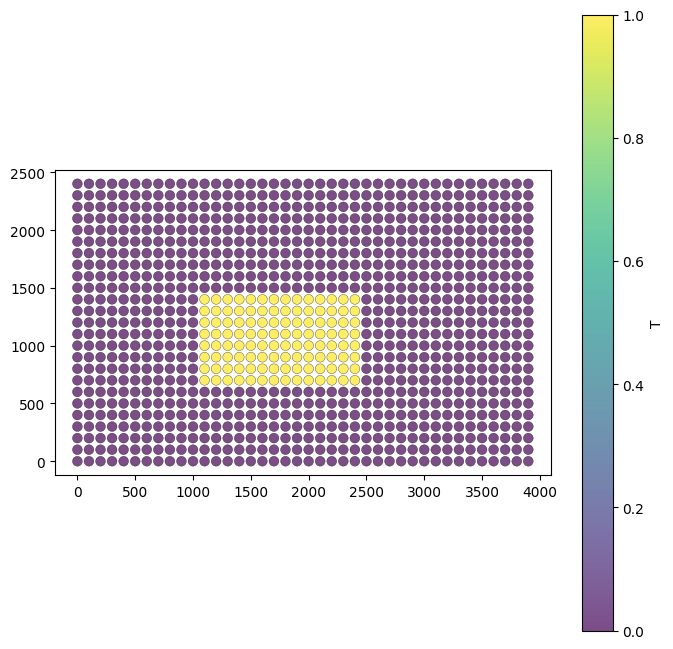

In [6]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='T')

<Axes: >

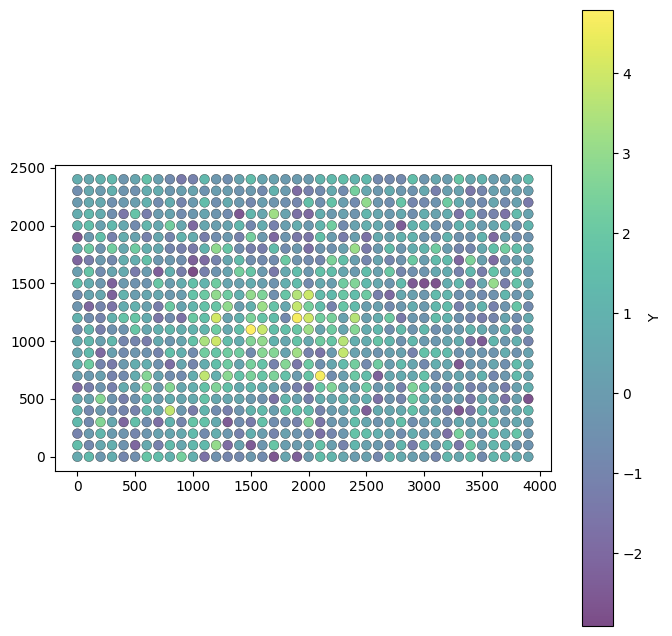

In [7]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y')

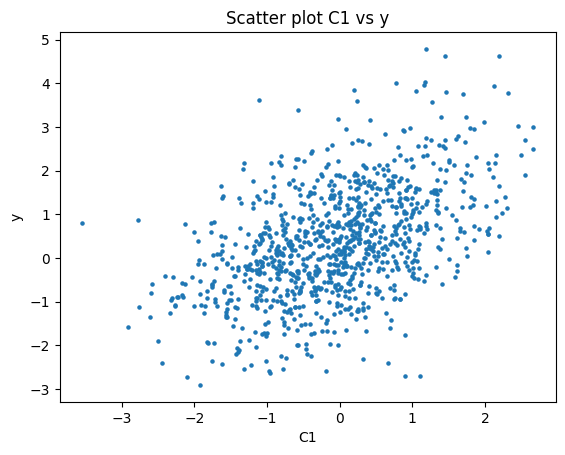

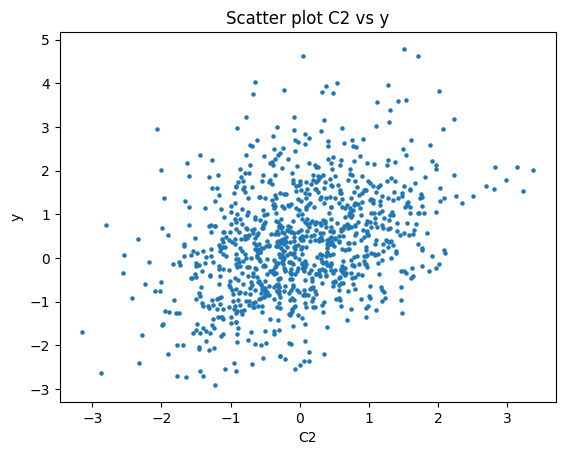

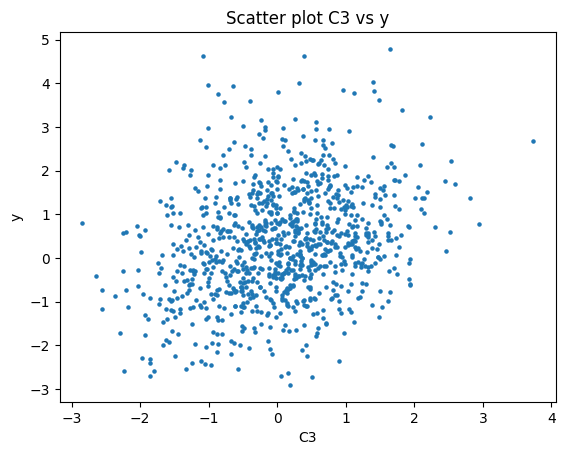

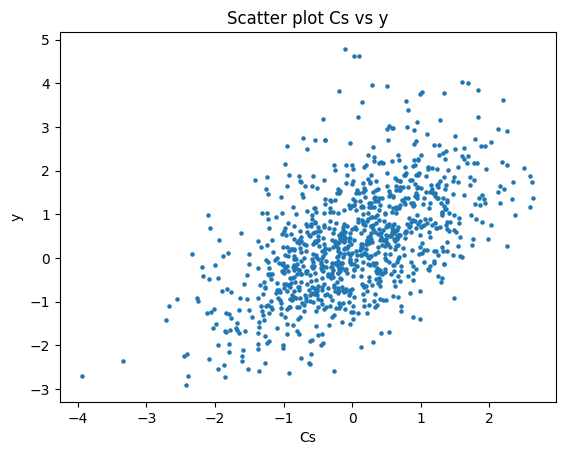

In [8]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [9]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y"].values.reshape(-1,1)
T = gdf_output["T"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
y_l = gdf_output["Y_ns"]
Y = gdf_output['Y'].values

X_logit = sm.add_constant(X)

##### Logit for T

In [10]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.349331
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                0.003838
Time:                        17:48:44   Log-Likelihood:                -349.33
converged:                       True   LL-Null:                       -350.68
Covariance Type:            nonrobust   LLR p-value:                    0.2603
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0743      0.101    -20.556      0.000      -2.272      -1.876
x1             0.1087      0.

##### Cross sectional linear difference in differences 

In [11]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   Y_ns   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     362.0
Date:                Wed, 29 Apr 2026   Prob (F-statistic):          6.21e-159
Time:                        17:48:47   Log-Likelihood:                -1258.4
No. Observations:                1000   AIC:                             2525.
Df Residuals:                     996   BIC:                             2544.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2122      0.029      7.391      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [12]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 

model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :           Y                Number of Observations:        1000
Mean dependent var  :      0.3528                Number of Variables   :           8
S.D. dependent var  :      1.2502                Degrees of Freedom    :         992
Pseudo R-squared    :      0.5369
Spatial Pseudo R-squared:  0.5349
Log likelihood      :  -1257.5875
Sigma-square ML     :      0.7231                Akaike info criterion :    2531.175
S.E of regression   :      0.8504                Schwarz criterion     :    2570.437

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----

##### Basic causal forest

In [13]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

,unit_id,geometry,T,tau,tau_cf
282,1282,POINT (1100 700),1,1.875805,2.338857
283,1283,POINT (1100 800),1,1.088087,1.349573
284,1284,POINT (1100 900),1,1.482632,1.698878
285,1285,POINT (1100 1000),1,1.576309,2.039770
286,1286,POINT (1100 1100),1,1.177525,1.218580
...,...,...,...,...,...
610,1610,POINT (2400 1000),1,1.657530,2.041318
611,1611,POINT (2400 1100),1,2.232604,1.674122
612,1612,POINT (2400 1200),1,1.760760,2.170483
613,1613,POINT (2400 1300),1,1.749593,1.388289


In [14]:
ci_low_ate, ate, ci_high_ate

(np.float64(1.5434411152345473),
 np.float64(1.5682824422288513),
 np.float64(1.5931237692231552))

In [15]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

np.float64(1.571682771204511)

## Generating multiple df for simulations

### Data generation

### Data saving

In [ ]:
conn = sqlite3.connect(r"C:\Users\andre\Desktop\IDS\02_VS_code\02_building_permits_and_regeneration\00_Data\lodz_regeneration_bpd.sqlite")
cursor = conn.cursor()